# Optional PCHIP interpolation for atomic scattering factors

Compares the **unchanged `periodictable` default** (linear $f_1$, log-log $f_2$) to optional shape-preserving cubic PCHIP for the same tabulated data. Includes the Au L$_3$ absorption edge and the corresponding complex Au–water contrast for ASAXS.

Install `scipy` only if you want PCHIP: `python -m pip install --dry-run -e ".[spline]"` to preview the environment changes, then install if appropriate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from atomic_scattering_factors import get_scattering_factors, effective_electron_density

ENERGIES = np.linspace(11500, 12200, 501)  # eV, near Au L3 edge
SCALING = 1e-30  # electrons/m³ -> electrons/Å³

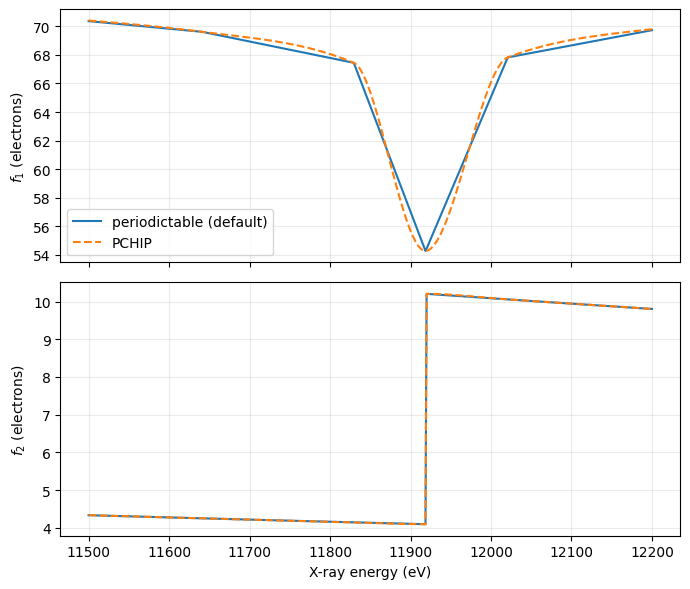

In [2]:
f1_default, f2_default = get_scattering_factors("Au", ENERGIES)
f1_pchip, f2_pchip = get_scattering_factors("Au", ENERGIES, interpolation="pchip")

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].plot(ENERGIES, f1_default, label="periodictable (default)")
axes[0].plot(ENERGIES, f1_pchip, "--", label="PCHIP")
axes[0].set_ylabel(r"$f_1$ (electrons)")
axes[1].plot(ENERGIES, f2_default)
axes[1].plot(ENERGIES, f2_pchip, "--")
axes[1].set_ylabel(r"$f_2$ (electrons)")
axes[1].set_xlabel("X-ray energy (eV)")
axes[0].legend()
for ax in axes: ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

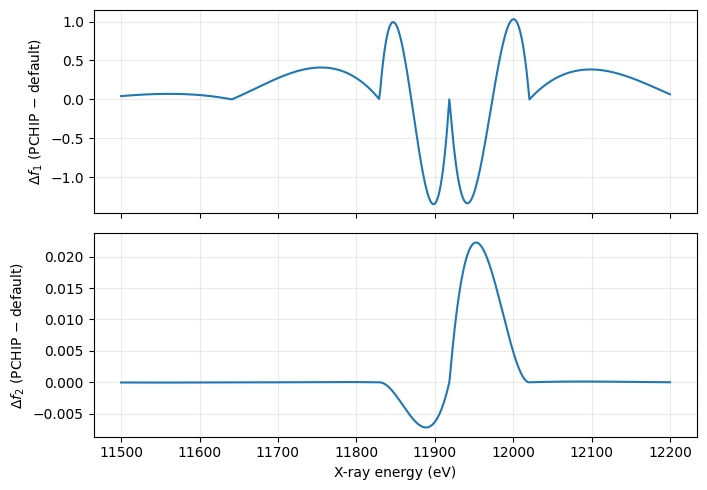

Max |Δf1|: 1.3459
Max |Δf2|: 0.022239


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
axes[0].plot(ENERGIES, f1_pchip - f1_default)
axes[0].set_ylabel(r"$\Delta f_1$ (PCHIP − default)")
axes[1].plot(ENERGIES, f2_pchip - f2_default)
axes[1].set_ylabel(r"$\Delta f_2$ (PCHIP − default)")
axes[1].set_xlabel("X-ray energy (eV)")
for ax in axes: ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Max |Δf1|: {np.max(np.abs(f1_pchip - f1_default)):.5g}")
print(f"Max |Δf2|: {np.max(np.abs(f2_pchip - f2_default)):.5g}")

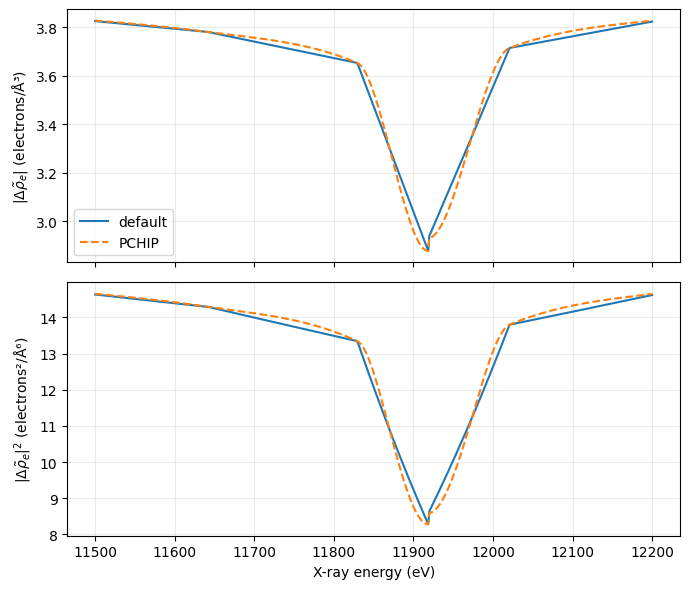

In [4]:
def contrast(energies, interpolation):
    rho_gold = effective_electron_density("Au", energies_eV=energies, complex=True, interpolation=interpolation)
    rho_water = effective_electron_density("H2O", 1.0, energies, complex=True, interpolation=interpolation)
    return (rho_gold - rho_water) * SCALING

contrast_default = contrast(ENERGIES, "default")
contrast_pchip = contrast(ENERGIES, "pchip")

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].plot(ENERGIES, np.abs(contrast_default), label="default")
axes[0].plot(ENERGIES, np.abs(contrast_pchip), "--", label="PCHIP")
axes[0].set_ylabel(r"$|\Delta\tilde\rho_e|$ (electrons/Å³)")
axes[0].legend()
axes[1].plot(ENERGIES, np.abs(contrast_default)**2)
axes[1].plot(ENERGIES, np.abs(contrast_pchip)**2, "--")
axes[1].set_ylabel(r"$|\Delta\tilde\rho_e|^2$ (electrons²/Å⁶)")
axes[1].set_xlabel("X-ray energy (eV)")
for ax in axes: ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Interpretation:** Both results use the same source tabulation. Neither interpolation can reproduce sample-specific absorption fine structure. Close to an absorption edge, experimentally measured anomalous corrections can be preferable for quantitative ASAXS.